In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import ipywidgets as widgets
from ipywidgets import VBox, HBox, Layout
from IPython.display import display, clear_output
from scipy.spatial.distance import pdist
import folium
import random
import time

## Objective Function : Solar suitability score

In [2]:
# To be adjusted
def calculate_suitability(row, w0=0.8, w1=0.3, w2=-0.2, w3=-0.2):
    return w0 * row['ALLSKY_SFC_SW_DWN'] + w1 * row['ALLSKY_KT'] + w2 * row['CLOUD_AMT'] + w3 * row['PRECTOTCORR']


## Genetic Algo

In [2]:
# Load the installed solar power plant coordinates
solar_df = pd.read_csv("turkey_solar_power_plants.csv")

# Create a list of (lat, lon) tuples to pass into the GA as proximity references
solar_sites = list(zip(solar_df["latitude"], solar_df["longitude"]))


In [3]:
def genetic_algorithm(df, population_size, generations, mutation_rate, num_points=20, verbose=False):
    df = df.copy()
    start_time = time.time()  # ⏱️ Start timing

    def fitness_function(point_indices):
        points = df.loc[point_indices]
        suitability_score = points['avg_score'].sum()

        # --- Grid proximity penalty among selected points ---
        intra_penalty = 0
        lat_array = points['lat'].values
        lon_array = points['lon'].values

        for i in range(len(points)):
            for j in range(i + 1, len(points)):
                lat_diff_km = abs(lat_array[i] - lat_array[j]) * 111
                lon_diff_km = abs(lon_array[i] - lon_array[j]) * 86.25
                distance_km = np.sqrt(lat_diff_km**2 + lon_diff_km**2)
                if distance_km < 100:
                    intra_penalty += 1 / (distance_km + 1e-6)

        # --- Proximity penalty to real solar plants ---
        proximity_penalty = 0
        if solar_sites is not None:
            for row in points.itertuples():
                for solar_lat, solar_lon in solar_sites:
                    lat_diff_km = abs(row.lat - solar_lat) * 111
                    lon_diff_km = abs(row.lon - solar_lon) * 86.25
                    dist = np.sqrt(lat_diff_km**2 + lon_diff_km**2)
                    if dist < 50:
                        proximity_penalty += 1 / (dist + 1e-6)

        lambda_intra = 10
        lambda_prox = 10
        total_penalty = lambda_intra * intra_penalty + lambda_prox * proximity_penalty

        return suitability_score - total_penalty

    def create_initial_population():
        return [np.random.choice(df.index, num_points, replace=False) for _ in range(population_size)]

    def selection(population, fitnesses):
        indices = np.argsort(fitnesses)
        return [population[i] for i in indices[-(population_size // 2):]]

    def crossover(parent1, parent2):
        child = list(dict.fromkeys(np.concatenate((parent1, parent2))))  # remove duplicates, keep order
        while len(child) < len(parent1):
            new_point = random.choice([i for i in df.index if i not in child])
            child.append(new_point)
        return np.array(child[:len(parent1)]), np.array(child[:len(parent1)])

    def mutate(individual, mutation_rate):
        if random.random() < mutation_rate:
            idx = random.randint(0, len(individual) - 1)
            new_point = random.choice([i for i in df.index if i not in individual])
            individual[idx] = new_point

    fitness_scores = []
    population = create_initial_population()
    best_individual = None
    best_fitness = -float('inf')

    for generation in range(generations):
        fitnesses = [fitness_function(ind) for ind in population]

        if max(fitnesses) > best_fitness:
            best_fitness = max(fitnesses)
            best_individual = population[np.argmax(fitnesses)]

        selected = selection(population, fitnesses)
        next_generation = []

        while len(next_generation) < population_size:
            parents = random.sample(selected, 2)
            offspring1, offspring2 = crossover(parents[0], parents[1])
            mutate(offspring1, mutation_rate)
            mutate(offspring2, mutation_rate)
            next_generation.extend([offspring1, offspring2])

        population = next_generation[:population_size]

        if verbose and generation % 10 == 0:
            print(f"Generation {generation + 1}, Best Fitness: {best_fitness:.4f}")

        fitness_scores.append(best_fitness)

    best_points = df.loc[best_individual]
    best_points.to_csv('best_20_points_penalty.csv', index=False)
    print("Best 20 points saved to 'best_20_points_penalty.csv'")

    end_time = time.time()  # ⏱️ End timing
    runtime = end_time - start_time
    print(f"⏱️ Runtime: {runtime:.2f} seconds")

    return best_individual, best_fitness, fitness_scores, runtime


In [47]:
# Run the algorithm with fixed parameters
if __name__ == "__main__":
    file_path = r"lat_lon_avg_score.csv"
    df_input = pd.read_csv(file_path)

    
    best_assignment_ga, best_fitness_ga, fitness_scores_ga,runtime_ga = genetic_algorithm(
        df=df_input,
        population_size=50,
        generations=200,
        mutation_rate=0.2,
        num_points=20,
        verbose=True
    )

Generation 1, Best Fitness: 7.2355
Generation 11, Best Fitness: 8.6742
Generation 21, Best Fitness: 10.1263
Generation 31, Best Fitness: 10.7245
Generation 41, Best Fitness: 11.5899
Generation 51, Best Fitness: 11.6849
Generation 61, Best Fitness: 12.0205
Generation 71, Best Fitness: 12.2091
Generation 81, Best Fitness: 12.6010
Generation 91, Best Fitness: 12.6010
Generation 101, Best Fitness: 12.6010
Generation 111, Best Fitness: 12.8898
Generation 121, Best Fitness: 12.8898
Generation 131, Best Fitness: 13.0094
Generation 141, Best Fitness: 13.0526
Generation 151, Best Fitness: 13.2088
Generation 161, Best Fitness: 13.2750
Generation 171, Best Fitness: 13.2750
Generation 181, Best Fitness: 13.2750
Generation 191, Best Fitness: 13.2750
Best 20 points saved to 'best_20_points_penalty.csv'
⏱️ Runtime: 34.95 seconds


## Greedy top-20 strategy


In [48]:
# Load the dataset with lat, lon, and avg_score
df = pd.read_csv("lat_lon_avg_score.csv")

# Select the top 20 points with the highest avg_score
top_20_points = df.nlargest(20, 'avg_score')

# Save to CSV
output_path_top20 = "top_20_points_direct.csv"
top_20_points.to_csv(output_path_top20, index=False)

output_path_top20


'top_20_points_direct.csv'

## Experiments with GA


In [5]:
# initializing the experiment variables
pop_size = [25,50,75,100]
mut_rate = [0.05,0.1,0.2,0.3,0.5]

### Population Size Experiments 


In [53]:
pop_results = []

for pop in pop_size:
    best_assignment_ga, best_fitness_ga, fitness_scores_ga, runtime_ga = genetic_algorithm(
        df=df_input.copy(),       # ensure original data is preserved
        population_size=pop,
        generations=200,
        mutation_rate=0.2,
        num_points=20,
        verbose=True
    )
    print(f"Population Size: {pop}, Best Fitness: {best_fitness_ga}")
    pop_results.append([best_assignment_ga, best_fitness_ga, fitness_scores_ga])


Generation 1, Best Fitness: 6.7642
Generation 11, Best Fitness: 8.3773
Generation 21, Best Fitness: 9.2365
Generation 31, Best Fitness: 9.6256
Generation 41, Best Fitness: 9.9935
Generation 51, Best Fitness: 10.8504
Generation 61, Best Fitness: 11.6701
Generation 71, Best Fitness: 11.6825
Generation 81, Best Fitness: 12.0065
Generation 91, Best Fitness: 12.2284
Generation 101, Best Fitness: 12.4983
Generation 111, Best Fitness: 12.7291
Generation 121, Best Fitness: 12.7627
Generation 131, Best Fitness: 12.9077
Generation 141, Best Fitness: 12.9077
Generation 151, Best Fitness: 12.9077
Generation 161, Best Fitness: 12.9604
Generation 171, Best Fitness: 12.9995
Generation 181, Best Fitness: 13.1508
Generation 191, Best Fitness: 13.1508
Best 20 points saved to 'best_20_points_penalty.csv'
⏱️ Runtime: 19.18 seconds
Population Size: 25, Best Fitness: 13.303160157004625
Generation 1, Best Fitness: 7.0333
Generation 11, Best Fitness: 8.2217
Generation 21, Best Fitness: 9.5195
Generation 31, B

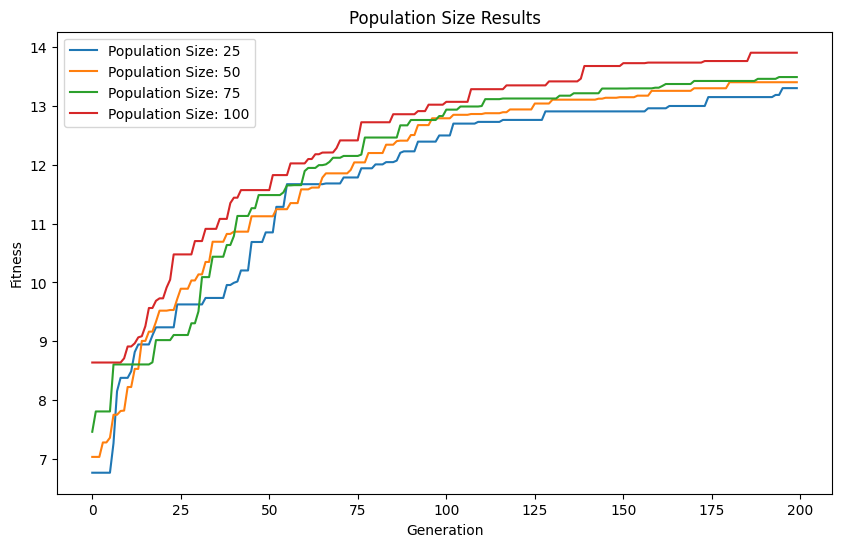

In [54]:
plt.figure(figsize=(10, 6))
for i, result in enumerate(pop_results):
    plt.plot(result[2], label=f"Population Size: {pop_size[i]}")
plt.xlabel("Generation")
plt.ylabel("Fitness")
plt.legend()
plt.title("Population Size Results")
plt.show()

### Mutation Rate Experiments

In [61]:
mut_results = []
for mut in mut_rate:
    best_assignment_ga, best_fitness_ga, fitness_scores_ga,runtime_ga = genetic_algorithm(
        df=df_input.copy(),       # ensure original data is preserved
        population_size=50,
        generations=300,
        mutation_rate=mut,
        num_points=20,
        verbose=True
    )
    print(f"Mutation Rate: {mut}, Best Fitness: {best_fitness_ga}")
    mut_results.append([best_assignment_ga, best_fitness_ga, fitness_scores_ga])

Generation 1, Best Fitness: 6.4408
Generation 11, Best Fitness: 7.2780
Generation 21, Best Fitness: 8.6348
Generation 31, Best Fitness: 9.7305
Generation 41, Best Fitness: 9.8175
Generation 51, Best Fitness: 10.6115
Generation 61, Best Fitness: 10.8725
Generation 71, Best Fitness: 11.3089
Generation 81, Best Fitness: 11.6248
Generation 91, Best Fitness: 11.7328
Generation 101, Best Fitness: 11.8916
Generation 111, Best Fitness: 11.9561
Generation 121, Best Fitness: 12.1307
Generation 131, Best Fitness: 12.1307
Generation 141, Best Fitness: 12.1695
Generation 151, Best Fitness: 12.3885
Generation 161, Best Fitness: 12.4855
Generation 171, Best Fitness: 12.6012
Generation 181, Best Fitness: 12.6012
Generation 191, Best Fitness: 12.6270
Generation 201, Best Fitness: 12.6404
Generation 211, Best Fitness: 12.7608
Generation 221, Best Fitness: 12.8231
Generation 231, Best Fitness: 13.1587
Generation 241, Best Fitness: 13.2311
Generation 251, Best Fitness: 13.2311
Generation 261, Best Fitness

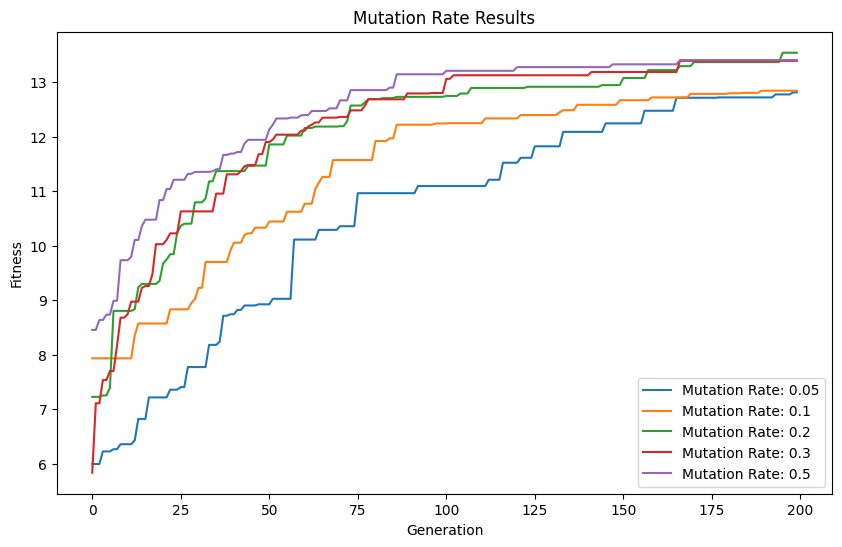

In [60]:
plt.figure(figsize=(10, 6))
for mut, result in zip(mut_rate, mut_results):
    plt.plot(result[2], label=f"Mutation Rate: {mut}")
plt.xlabel("Generation")
plt.ylabel("Fitness")
plt.title("Mutation Rate Results")
plt.legend()
plt.show()

### Generations Number Experiments

In [6]:
# Load your dataset
file_path = r"lat_lon_avg_score.csv"
df_input = pd.read_csv(file_path)

# Run the genetic algorithm
best_assignment_ga, best_fitness_ga, fitness_scores_ga,runtime_ga = genetic_algorithm(
    df=df_input.copy(),
    population_size=50,
    generations=2000,
    mutation_rate=0.2,
    num_points=20,
    verbose=True
)

Generation 1, Best Fitness: 6.2220
Generation 11, Best Fitness: 6.8742
Generation 21, Best Fitness: 8.5907
Generation 31, Best Fitness: 9.4743
Generation 41, Best Fitness: 10.1782
Generation 51, Best Fitness: 11.0808
Generation 61, Best Fitness: 11.1590
Generation 71, Best Fitness: 11.5071
Generation 81, Best Fitness: 11.8147
Generation 91, Best Fitness: 12.1204
Generation 101, Best Fitness: 12.3420
Generation 111, Best Fitness: 12.5371
Generation 121, Best Fitness: 12.5440
Generation 131, Best Fitness: 12.8150
Generation 141, Best Fitness: 12.8150
Generation 151, Best Fitness: 12.9037
Generation 161, Best Fitness: 13.0002
Generation 171, Best Fitness: 13.0834
Generation 181, Best Fitness: 13.0834
Generation 191, Best Fitness: 13.2747
Generation 201, Best Fitness: 13.2747
Generation 211, Best Fitness: 13.2747
Generation 221, Best Fitness: 13.4194
Generation 231, Best Fitness: 13.4194
Generation 241, Best Fitness: 13.4194
Generation 251, Best Fitness: 13.4194
Generation 261, Best Fitnes

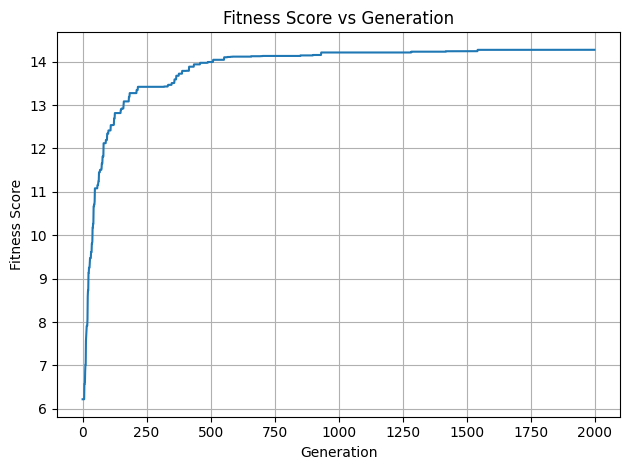

In [7]:
# Plot the fitness scores
plt.plot(fitness_scores_ga)
plt.xlabel("Generation")
plt.ylabel("Fitness Score")
plt.title("Fitness Score vs Generation")
plt.grid(True)
plt.tight_layout()
plt.show()

## Interactive GA

In [9]:
# --- Load your data ---
df_input = pd.read_csv("lat_lon_avg_score.csv")

# --- Layouts ---
slider_layout = Layout(width='600px', height='50px')
button_layout = Layout(width='300px', height='50px')

# --- Sliders ---
population_slider = widgets.IntSlider(
    value=50, min=25, max=100, step=10,
    description='👥 Population:', style={'description_width': '150px'},
    layout=slider_layout
)
mutation_slider = widgets.FloatSlider(
    value=0.2, min=0.01, max=1, step=0.01,
    description='🧬 Mutation Rate:', style={'description_width': '150px'},
    layout=slider_layout
)
generation_slider = widgets.IntSlider(
    value=300, min=50, max=2000, step=50,
    description='🔁 Generations:', style={'description_width': '150px'},
    layout=slider_layout
)

# --- Buttons ---
run_button = widgets.Button(
    description="🚀 Run Optimization",
    button_style='success',
    layout=button_layout
)
reset_button = widgets.Button(
    description="🔄 Reset",
    button_style='warning',
    layout=button_layout
)

# --- Output box ---
output = widgets.Output()

# --- Run callback ---
def on_button_click(b):
    with output:
        clear_output(wait=True)
        best_assignment, best_fitness, fitness_scores,runtime_ga = genetic_algorithm(
            df=df_input.copy(),
            population_size=population_slider.value,
            generations=generation_slider.value,
            mutation_rate=mutation_slider.value,
            num_points=20,
            verbose=True
        )
        # Fitness Plot
        fig1, ax1 = plt.subplots(figsize=(8, 4), constrained_layout=True)
        ax1.plot(fitness_scores, marker='o', color='mediumseagreen')
        ax1.set_title("📈 Fitness Score per Generation")
        ax1.set_xlabel("Generation")
        ax1.set_ylabel("Best Fitness")
        ax1.grid(True)
        plt.show()
        # Map Plot
        world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
        turkey = world[world.name == "Turkey"]
        selected_points = pd.read_csv('best_20_points_ga_penalty.csv')
        gdf_points = gpd.GeoDataFrame(
            selected_points,
            geometry=gpd.points_from_xy(selected_points.lon, selected_points.lat),
            crs="EPSG:4326"
        )
        fig2, ax2 = plt.subplots(figsize=(8, 10), constrained_layout=True)
        turkey.plot(ax=ax2, color='whitesmoke', edgecolor='black')
        gdf_points.plot(ax=ax2, color='crimson', markersize=50, edgecolor='white')
        ax2.set_title("📍 Selected Solar Installation Points on Türkiye Map", fontsize=14)
        ax2.set_xlabel("Longitude")
        ax2.set_ylabel("Latitude")
        ax2.grid(True)
        plt.show()

# --- Reset callback ---
def on_reset_click(b):
    population_slider.value = 50
    mutation_slider.value = 0.2
    generation_slider.value = 300
    output.clear_output()

# --- Remove duplicate bindings and bind cleanly ---
def clear_and_bind(widget, callback):
    try:
        widget._click_handlers.callbacks.clear()
    except Exception:
        pass
    widget.on_click(callback)

clear_and_bind(run_button, on_button_click)
clear_and_bind(reset_button, on_reset_click)


# --- Layout container ---
button_row = HBox([run_button, reset_button], layout=Layout(justify_content='center', gap='20px'))
control_box = VBox(
    [population_slider, mutation_slider, generation_slider, button_row],
    layout=Layout(
        border='2px solid lightgray',
        border_radius='10px',
        box_shadow='2px 2px 5px rgba(0,0,0,0.1)',
        padding='20px',
        width='700px',
        align_items='center',
        background_color='white'
    )
)

# --- Output box with wider layout ---
output.layout = Layout(width='900px', align_items='center')

if not hasattr(run_button, "_already_displayed"):
    display(VBox([control_box, widgets.HBox([output], layout=Layout(justify_content='center', width='100%'))], 
                 layout=Layout(align_items='center', width='100%')))
    run_button._already_displayed = True

## Particle Swarm

In [31]:
class Particle:
    def __init__(self, df, num_points):
        self.df = df
        self.num_points = num_points
        
        # Initialize particle with random selection of points
        self.position = np.random.choice(df.index, num_points, replace=False)
        self.velocity = []  # Not used in this discrete version
        self.best_position = self.position.copy()
        self.best_score = self.fitness(self.position)

    def fitness(self, indices):
        points = self.df.loc[indices]
        suitability_score = points['avg_score'].sum()

        # Apply penalty for points that are too close to each other
        penalty = 0
        lat_array = points['lat'].values
        lon_array = points['lon'].values

        for i in range(len(points)):
            for j in range(i + 1, len(points)):
                lat_diff_km = abs(lat_array[i] - lat_array[j]) * 111  # approx. km/degree
                lon_diff_km = abs(lon_array[i] - lon_array[j]) * 86.25
                distance_km = np.sqrt(lat_diff_km**2 + lon_diff_km**2)

                if distance_km < 100:
                    penalty += 1 / (distance_km + 1e-6)  # Avoid division by zero

        lambda_penalty = 10
        return suitability_score - lambda_penalty * penalty

    def update(self, global_best):
        new_position = self.position.copy()

        # Replace points based on personal and global bests
        for i in range(len(self.position)):
            if random.random() < 0.5:
                new_position[i] = global_best[i]
            elif random.random() < 0.5:
                new_position[i] = self.best_position[i]

        # Ensure all selected indices are unique
        self.position = np.unique(new_position)
        while len(self.position) < self.num_points:
            candidate = random.choice(self.df.index)
            if candidate not in self.position:
                self.position = np.append(self.position, candidate)

        # Update personal best
        current_score = self.fitness(self.position)
        if current_score > self.best_score:
            self.best_position = self.position.copy()
            self.best_score = current_score


In [32]:
def particle_swarm_optimization(df, num_particles=30, iterations=35, num_points=20, verbose=True):
    df = df.copy()
    swarm = [Particle(df, num_points) for _ in range(num_particles)]

    # Initialize global best
    global_best_position = swarm[0].position.copy()
    global_best_score = swarm[0].fitness(global_best_position)

    best_scores = []

    for iteration in range(iterations):
        # Linear inertia decay from 0.9 to 0.3
        inertia = 0.9 - iteration * ((0.9 - 0.3) / iterations)

        for particle in swarm:
            particle.update(global_best_position)

            if particle.best_score > global_best_score:
                global_best_position = particle.best_position.copy()
                global_best_score = particle.best_score

        best_scores.append(global_best_score)

        if verbose and iteration % 5 == 0:
            print(f"Iteration {iteration + 1}, Inertia: {inertia:.3f}, Best Fitness: {global_best_score:.4f}")

    # Save results
    best_points_df = df.loc[global_best_position]
    best_points_df.to_csv('best_20_points_pso.csv', index=False)
    print("Best 20 points saved to 'best_20_points_pso.csv'")

    return global_best_position, global_best_score, best_scores


In [33]:
best_assignment, best_fitness, fitness_scores = particle_swarm_optimization(
    df=df,
    num_particles=50,
    iterations=100,
    num_points=20,
    verbose=True
)


Iteration 1, Inertia: 0.900, Best Fitness: 10.9300
Iteration 6, Inertia: 0.870, Best Fitness: 12.2498
Iteration 11, Inertia: 0.840, Best Fitness: 13.0372
Iteration 16, Inertia: 0.810, Best Fitness: 13.1744
Iteration 21, Inertia: 0.780, Best Fitness: 13.5437
Iteration 26, Inertia: 0.750, Best Fitness: 13.6246
Iteration 31, Inertia: 0.720, Best Fitness: 13.6246
Iteration 36, Inertia: 0.690, Best Fitness: 13.6641
Iteration 41, Inertia: 0.660, Best Fitness: 13.6641
Iteration 46, Inertia: 0.630, Best Fitness: 13.6641
Iteration 51, Inertia: 0.600, Best Fitness: 13.7071
Iteration 56, Inertia: 0.570, Best Fitness: 13.8404
Iteration 61, Inertia: 0.540, Best Fitness: 13.8404
Iteration 66, Inertia: 0.510, Best Fitness: 13.8707
Iteration 71, Inertia: 0.480, Best Fitness: 13.9073
Iteration 76, Inertia: 0.450, Best Fitness: 13.9073
Iteration 81, Inertia: 0.420, Best Fitness: 13.9073
Iteration 86, Inertia: 0.390, Best Fitness: 13.9073
Iteration 91, Inertia: 0.360, Best Fitness: 13.9073
Iteration 96, 

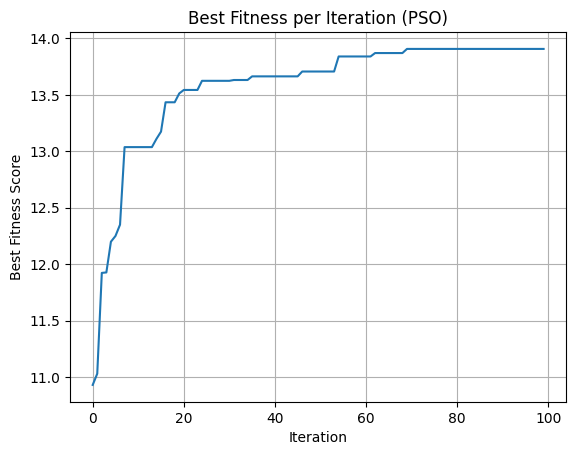

In [34]:
plt.plot(fitness_scores)
plt.title("Best Fitness per Iteration (PSO)")
plt.xlabel("Iteration")
plt.ylabel("Best Fitness Score")
plt.grid(True)
plt.show()


### Experiments With PSO

In [ ]:
df_input = pd.read_csv("lat_lon_avg_score.csv")

In [31]:
particle_sizes = [25, 50, 75, 100]
iterations = 100

pso_results = []

for n_particles in particle_sizes:
    best_assignment, best_fitness, fitness_scores = particle_swarm_optimization(
        df=df_input.copy(),
        num_particles=n_particles,
        iterations=iterations,
        num_points=20,
        verbose=True
    )
    print(f"Particle Size: {n_particles}, Best Fitness: {best_fitness:.4f}")
    pso_results.append([n_particles, best_assignment, best_fitness, fitness_scores])


Iteration 1, Inertia: 0.900, Best Fitness: 10.0973
Iteration 6, Inertia: 0.870, Best Fitness: 11.8909
Iteration 11, Inertia: 0.840, Best Fitness: 12.7226
Iteration 16, Inertia: 0.810, Best Fitness: 12.8190
Iteration 21, Inertia: 0.780, Best Fitness: 13.3160
Iteration 26, Inertia: 0.750, Best Fitness: 13.3398
Iteration 31, Inertia: 0.720, Best Fitness: 13.3398
Iteration 36, Inertia: 0.690, Best Fitness: 13.6404
Iteration 41, Inertia: 0.660, Best Fitness: 13.6404
Iteration 46, Inertia: 0.630, Best Fitness: 13.6635
Iteration 51, Inertia: 0.600, Best Fitness: 13.6880
Iteration 56, Inertia: 0.570, Best Fitness: 13.6880
Iteration 61, Inertia: 0.540, Best Fitness: 13.8083
Iteration 66, Inertia: 0.510, Best Fitness: 13.8083
Iteration 71, Inertia: 0.480, Best Fitness: 13.8083
Iteration 76, Inertia: 0.450, Best Fitness: 13.8428
Iteration 81, Inertia: 0.420, Best Fitness: 13.8451
Iteration 86, Inertia: 0.390, Best Fitness: 13.8890
Iteration 91, Inertia: 0.360, Best Fitness: 13.9106
Iteration 96, 

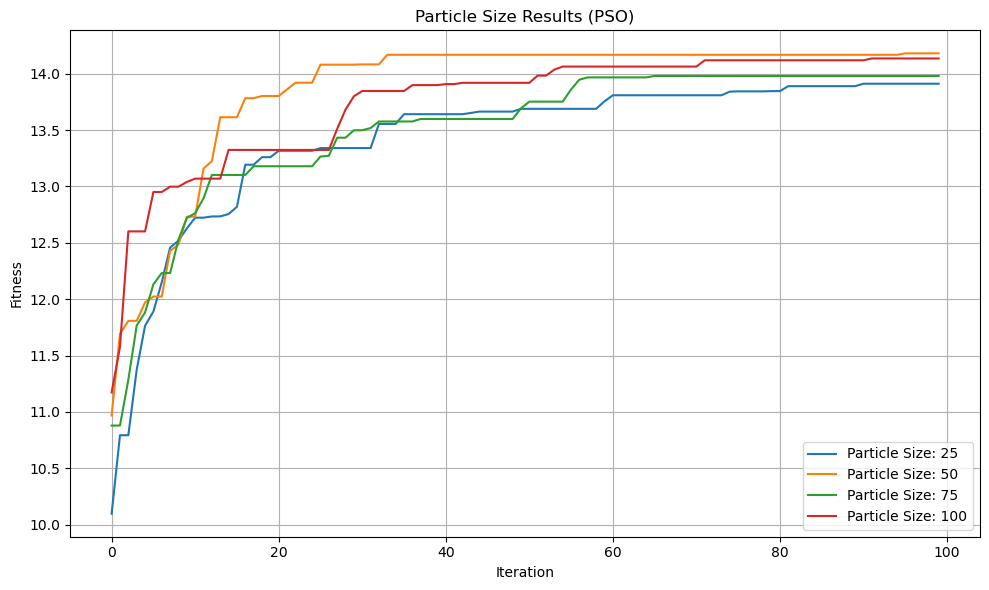

In [ ]:
plt.figure(figsize=(10, 6))

for i, result in enumerate(pso_results):
    plt.plot(result[3], label=f"Particle Size: {particle_sizes[i]}")

plt.xlabel("Iteration")
plt.ylabel("Fitness")
plt.title("Particle Size Results (PSO)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Comparison Between GA, PSO, SA and Greedy 

In [10]:
# === Load result files ===
ga_points = pd.read_csv("best_20_points_ga_penalty.csv")
pso_points = pd.read_csv("best_20_points_pso.csv")
top_20_points = pd.read_csv("top_20_points_direct.csv")

# === Define the evaluation function that accepts fitness & time ===
def evaluate_set(df, label, runtime_sec, best_fitness):
    coords = df[['lat', 'lon']].values
    distances = pdist(coords)
    return {
        "Method": label,
        "Best Fitness": round(best_fitness, 6),
        "Mean Score": round(df["avg_score"].mean(), 4),
        "Mean Distance (km)": round(distances.mean(), 2),
        "Min Distance (km)": round(distances.min(), 2),
        "Runtime (sec)": round(runtime_sec, 2)
    }
best_fitness_greedy = top_20_points["avg_score"].sum()

# === Build comparison table ===
results = [
    evaluate_set(top_20_points, "Top-20 Greedy", 0.01, best_fitness_greedy),
    evaluate_set(ga_points, "Genetic Algorithm", runtime_ga, best_fitness_ga),
    evaluate_set(pso_points, "Particle Swarm Optimization", pso_runtime, best_fitness_pso)
]

df_comparison = pd.DataFrame(results)
display(df_comparison)


NameError: name 'pso_runtime' is not defined

C:\Users\aya20\AppData\Local\Temp\ipykernel_22132\735342030.py:23: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres"))
C:\Users\aya20\AppData\Local\Temp\ipykernel_22132\735342030.py:40: UserWarning: Glyph 128205 (\N{ROUND PUSHPIN}) missing from current font.
  plt.tight_layout()
C:\Users\aya20\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128205 (\N{ROUND PUSHPIN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


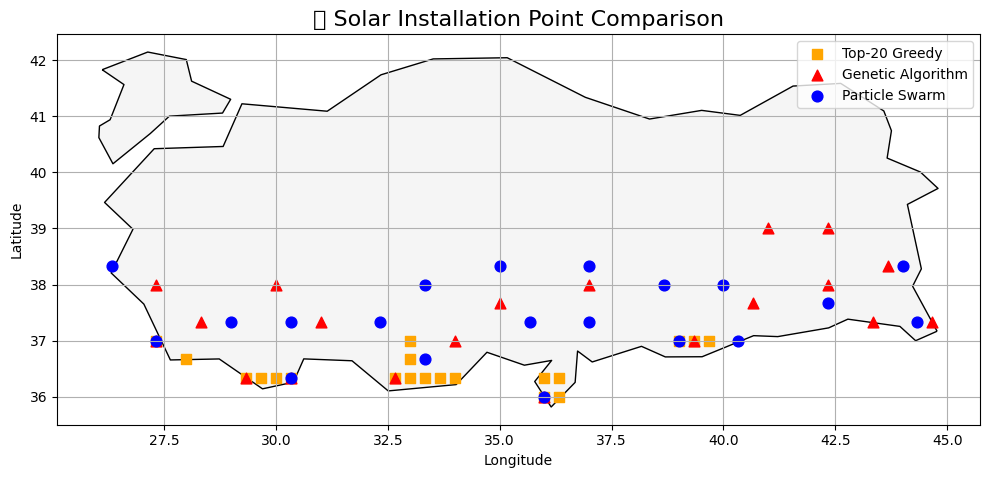

In [11]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# === Load result files ===
ga_df = pd.read_csv("best_20_points_ga_penalty.csv")
pso_df = pd.read_csv("best_20_points_pso.csv")
top20_df = pd.read_csv("top_20_points_direct.csv")

# === Convert to GeoDataFrames ===
def make_gdf(df):
    return gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df["lon"], df["lat"]),
        crs="EPSG:4326"
    )

gdf_ga = make_gdf(ga_df)
gdf_pso = make_gdf(pso_df)
gdf_top20 = make_gdf(top20_df)

# === Load Türkiye shape ===
world = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres"))
turkey = world[world.name == "Turkey"]

# === Plot all three sets ===
fig, ax = plt.subplots(figsize=(10, 12))
turkey.plot(ax=ax, color='whitesmoke', edgecolor='black')

gdf_top20.plot(ax=ax, color='orange', marker='s', markersize=60, label="Top-20 Greedy")
gdf_ga.plot(ax=ax, color='red', marker='^', markersize=60, label="Genetic Algorithm")
gdf_pso.plot(ax=ax, color='blue', marker='o', markersize=60, label="Particle Swarm")

# === Labels and layout ===
plt.title("📍 Solar Installation Point Comparison", fontsize=16)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [12]:
# === Load your result files ===
ga_df = pd.read_csv("best_20_points_ga_penalty.csv")
pso_df = pd.read_csv("best_20_points_pso.csv")
top20_df = pd.read_csv("top_20_points_direct.csv")

# === Load real solar power plant data ===
solar_df = pd.read_csv("turkey_solar_filtered.csv")  # name, gppd_idnr, capacity_mw, latitude, longitude

# === Center the map over Türkiye ===
center_lat = pd.concat([ga_df, pso_df, top20_df])["lat"].mean()
center_lon = pd.concat([ga_df, pso_df, top20_df])["lon"].mean()

# === Create satellite base map ===
m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=6,
    tiles=None,
    scrollWheelZoom=True,
    max_zoom=18,
    min_zoom=2,
    prefer_canvas=False,  # Needed for smoother interactions
    zoom_control=True
)

# ESRI Satellite
folium.TileLayer(
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}",
    attr="Esri World Imagery",
    name="Esri Satellite",
    overlay=False,
    control=True
).add_to(m)

# === Add optimization result layers ===
def add_markers(df, name, color):
    group = folium.FeatureGroup(name=name)

    max_score_idx = df['avg_score'].idxmax()  # index of the point with highest score
    max_score = df.loc[max_score_idx, 'avg_score']

    for i, row in df.iterrows():
        score = row['avg_score']
        radius = min(max((score - 0.5) * 30, 4), 12)  # scale between 4–12 (tweak as needed)

        if i == max_score_idx:
            # Use star icon for best-scoring point
            folium.Marker(
                location=[row['lat'], row['lon']],
                icon=folium.Icon(icon='star', color=color, prefix='fa'),
                popup=f"{name}<br><b>⭐ BEST</b><br>Score: {score:.4f}",
                tooltip=f"{name} – ⭐ Best<br>Score: {score:.4f}"
            ).add_to(group)
        else:
            folium.CircleMarker(
                location=[row['lat'], row['lon']],
                radius=radius,
                color=color,
                fill=True,
                fill_color=color,
                fill_opacity=0.85,
                popup=f"{name}<br>Score: {score:.4f}",
                tooltip=f"{name}<br>Score: {score:.4f}"
            ).add_to(group)
    group.add_to(m)


add_markers(top20_df, "Top-20 Greedy", "orange")
add_markers(ga_df, "Genetic Algorithm", "red")
add_markers(pso_df, "Particle Swarm Optimization", "blue")


# === Add real installed solar plants layer with variable size ===
solar_group = folium.FeatureGroup(name="☀ Installed Solar Plants")

# Get min/max capacity for normalization (optional: helps scale size adaptively)
min_cap = solar_df["capacity_mw"].min()
max_cap = solar_df["capacity_mw"].max()

for _, row in solar_df.iterrows():
    capacity = row['capacity_mw']

    # Normalize and scale radius from 4 to 16 (adjust range as needed)
    norm_capacity = (capacity - min_cap) / (max_cap - min_cap + 1e-6)
    radius = 4 + norm_capacity * 12  # radius between 4 and 16

    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=radius,
        color="green",
        fill=True,
        fill_color="green",
        fill_opacity=0.7,
        popup=f"{row['name']}<br>{capacity:.1f} MW",
        tooltip=f"{row['name']} – {capacity:.1f} MW"
    ).add_to(solar_group)

solar_group.add_to(m)


# === Add layer control toggle ===
folium.LayerControl().add_to(m)

# === Display the map ===
m
